# MIRT++ — KBS Experiment Analysis (23 Datasets)

Complete analysis for the MIRT++ paper. **G-Mean is the primary metric** — the geometric
mean of per-class recall imposes a multiplicative penalty whenever any class recall
approaches zero, making it the most honest measure for severely imbalanced multiclass
classification (a high majority-class recall cannot mask minority-class failure).

Generated from `kbs_results_raw.csv` (7,260 evaluations) and `kbs_timings.csv`.


In [1]:
# Cell 1 — dependencies (safe to run on Colab; no-op if already installed)
try:
    import scikit_posthocs, seaborn  # noqa
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable,'-m','pip','install','-q',
                    'scikit-posthocs','seaborn','matplotlib','pandas','scipy'])
print('Dependencies ready.')

Dependencies ready.


In [2]:
# Cell 2 — imports & global settings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display

plt.rcParams.update({'figure.dpi':120,'savefig.bbox':'tight','font.size':11,
                     'axes.titlesize':13,'axes.labelsize':12})

METHOD_ORDER = ['None','SMOTE','Borderline-SMOTE','ADASYN','SMOTE-ENN',
                'SMOTE-Tomek','KMeans-SMOTE','Safe-Level-SMOTE','MWMOTE','ProWSyn','MIRT++']
COLORS = ['#6c757d','#4285f4','#34a853','#fbbc04','#ea4335',
          '#9c27b0','#ff6d00','#00bcd4','#795548','#607d8b','#e91e63']
PALETTE = dict(zip(METHOD_ORDER, COLORS))

# Medical datasets present in this study (matches the experiment's medical case study)
MEDICAL = ['ann-thyroid','cleveland','dermatology','hepatitis','new-thyroid']
print('Setup complete —', len(METHOD_ORDER), 'methods; MIRT++ highlighted in pink.')

Setup complete — 11 methods; MIRT++ highlighted in pink.


In [3]:
# Cell 3 — load data (works locally AND on Colab)
import os

def _find(fname):
    # search common locations: cwd, Colab default, Google Drive
    cands = [fname, f'/content/{fname}',
             f'/content/drive/MyDrive/MIRT_Experiment/results/{fname}',
             f'/content/drive/MyDrive/MIRT_Experiment/{fname}']
    for c in cands:
        if os.path.exists(c):
            return c
    return None

def _load(fname):
    p = _find(fname)
    if p is None:
        # On Colab, prompt an upload; otherwise raise a clear error
        try:
            from google.colab import files
            print(f'>>> {fname} not found. Please upload it now:')
            up = files.upload()
            key = fname if fname in up else list(up.keys())[0]
            return pd.read_csv(key)
        except ImportError:
            raise FileNotFoundError(
                f'{fname} not found. Put it in this folder, or set the path manually.')
    print(f'Loaded {fname}  <-  {p}')
    return pd.read_csv(p)

raw = _load('kbs_results_raw.csv')
raw['resampler'] = raw['resampler'].fillna('None').replace('', 'None')

tim = _load('kbs_timings.csv')
tim['method'] = tim['method'].fillna('None').replace('', 'None')

DATASETS = sorted(raw['dataset'].unique())
N_DS = len(DATASETS)
TIMED = sorted(tim['dataset'].unique())
print(f'\nDatasets: {N_DS}  |  Rows: {len(raw):,}  |  Classifiers: {list(raw.clf.unique())}')
print(f'Datasets with timing data: {len(TIMED)}')
print(DATASETS)

Loaded kbs_results_raw.csv  <-  kbs_results_raw.csv
Loaded kbs_timings.csv  <-  kbs_timings.csv

Datasets: 23  |  Rows: 7,260  |  Classifiers: ['KNN', 'CART', 'SVM']
Datasets with timing data: 11
['abalone', 'ann-thyroid', 'balance-scale', 'car', 'cleveland', 'cmc', 'dermatology', 'ecoli', 'flare', 'glass', 'hayes-roth', 'hepatitis', 'new-thyroid', 'pendigits', 'satimage', 'segment', 'splice', 'vehicle', 'vowel', 'wine', 'winequality-red', 'winequality-white', 'yeast']


---
## Tables

In [4]:
# T1 — Dataset characteristics (n, features, classes, imbalance ratio)
ds_info = {
  'wine':dict(n=178,f=13,c=3,ir=1.5),'vehicle':dict(n=846,f=18,c=4,ir=1.1),
  'vowel':dict(n=990,f=13,c=11,ir=1.0),'segment':dict(n=2310,f=19,c=7,ir=1.0),
  'pendigits':dict(n=10992,f=16,c=10,ir=1.1),'splice':dict(n=3190,f=60,c=3,ir=1.8),
  'cmc':dict(n=1473,f=9,c=3,ir=1.9),'hayes-roth':dict(n=160,f=4,c=3,ir=2.1),
  'hepatitis':dict(n=155,f=19,c=2,ir=3.8),'new-thyroid':dict(n=215,f=5,c=3,ir=5.0),
  'dermatology':dict(n=366,f=34,c=6,ir=5.6),'glass':dict(n=214,f=9,c=6,ir=8.4),
  'satimage':dict(n=6435,f=36,c=6,ir=2.4),'balance-scale':dict(n=625,f=4,c=3,ir=5.9),
  'cleveland':dict(n=294,f=13,c=5,ir=12.5),'flare':dict(n=1066,f=10,c=6,ir=23.3),
  'ann-thyroid':dict(n=7200,f=21,c=3,ir=45.8),'car':dict(n=1728,f=6,c=4,ir=18.6),
  'ecoli':dict(n=336,f=7,c=5,ir=39.1),'winequality-red':dict(n=1599,f=11,c=6,ir=68.1),
  'yeast':dict(n=1484,f=8,c=8,ir=23.1),'abalone':dict(n=4177,f=8,c=3,ir=9.7),
  'winequality-white':dict(n=4893,f=11,c=6,ir=109.9),
}
t1 = pd.DataFrame({d:ds_info[d] for d in DATASETS if d in ds_info}).T
t1.columns = ['Samples (n)','Features','Classes (k)','Imbalance Ratio']
t1.index.name='Dataset'; t1=t1.sort_values('Imbalance Ratio')
t1.to_csv('table_T1_dataset_characteristics.csv')
print('=== TABLE 1: Dataset Characteristics (23 datasets) ===')
display(t1.style.format({'Samples (n)':'{:.0f}','Features':'{:.0f}',
                         'Classes (k)':'{:.0f}','Imbalance Ratio':'{:.1f}'}))

=== TABLE 1: Dataset Characteristics (23 datasets) ===


,Samples (n),Features,Classes (k),Imbalance Ratio
Dataset,,,,
segment,2310,19,7,1.0
vowel,990,13,11,1.0
vehicle,846,18,4,1.1
pendigits,10992,16,10,1.1
wine,178,13,3,1.5
splice,3190,60,3,1.8
cmc,1473,9,3,1.9
hayes-roth,160,4,3,2.1
satimage,6435,36,6,2.4


In [5]:
# T2 — Mean performance (G-Mean primary), sorted by G-Mean
mean_perf = raw.groupby('resampler')[['gmean','f1','auc']].mean().reindex(METHOD_ORDER).round(4)
mean_perf.columns = ['Mean G-Mean','Mean F1','Mean AUC']; mean_perf.index.name='Method'
mp_sorted = mean_perf.sort_values('Mean G-Mean', ascending=False)
mp_sorted.to_csv('table_T2_mean_performance.csv')
print('=== TABLE 2: Mean Performance — sorted by G-Mean (primary metric) ===')
display(mp_sorted.style.highlight_max(axis=0,color='#c8e6c9')
                       .highlight_min(axis=0,color='#ffcdd2').format('{:.4f}'))
for col in mean_perf.columns:
    r = int(mean_perf[col].rank(ascending=False)['MIRT++'])
    print(f'  MIRT++ {col:12s}: {mean_perf.loc["MIRT++",col]:.4f}  (rank #{r}/11)')

=== TABLE 2: Mean Performance — sorted by G-Mean (primary metric) ===


,Mean G-Mean,Mean F1,Mean AUC
Method,,,
MIRT++,0.7586,0.6360,0.8195
SMOTE,0.7571,0.6339,0.8168
SMOTE-Tomek,0.7555,0.6282,0.8166
ProWSyn,0.7554,0.6355,0.8185
Borderline-SMOTE,0.7549,0.6332,0.8125
MWMOTE,0.7532,0.6290,0.8115
Safe-Level-SMOTE,0.7492,0.6335,0.8128
ADASYN,0.7466,0.6221,0.8211
KMeans-SMOTE,0.7461,0.6313,0.8118


  MIRT++ Mean G-Mean : 0.7586  (rank #1/11)
  MIRT++ Mean F1     : 0.6360  (rank #1/11)
  MIRT++ Mean AUC    : 0.8195  (rank #3/11)


In [6]:
# T3 — Per-dataset mean G-Mean
per_ds = (raw.groupby(['dataset','resampler'])['gmean'].mean()
             .unstack('resampler').reindex(columns=METHOD_ORDER).round(3))
per_ds.index.name='Dataset'; per_ds.to_csv('table_T3_per_dataset_gmean.csv')
wins = (per_ds.idxmax(axis=1)=='MIRT++').sum()
print(f'=== TABLE 3: Per-Dataset Mean G-Mean === (MIRT++ best on {wins}/{N_DS} datasets)')
display(per_ds.style.highlight_max(axis=1,color='#c8e6c9').format('{:.3f}'))

=== TABLE 3: Per-Dataset Mean G-Mean === (MIRT++ best on 4/23 datasets)


resampler,None,SMOTE,Borderline-SMOTE,ADASYN,SMOTE-ENN,SMOTE-Tomek,KMeans-SMOTE,Safe-Level-SMOTE,MWMOTE,ProWSyn,MIRT++
Dataset,,,,,,,,,,,
abalone,0.700,0.710,0.711,0.709,0.722,0.714,0.710,0.712,0.709,0.714,0.713
ann-thyroid,0.506,0.598,0.591,0.589,0.607,0.592,0.559,0.576,0.579,0.598,0.593
balance-scale,0.745,0.773,0.780,0.753,0.803,0.772,0.774,0.758,0.774,0.774,0.777
car,0.841,0.934,0.937,0.941,0.932,0.934,0.939,0.904,0.935,0.933,0.946
cleveland,0.449,0.463,0.456,0.474,0.446,0.473,0.471,0.444,0.454,0.465,0.472
cmc,0.564,0.580,0.578,0.564,0.566,0.578,0.576,0.577,0.578,0.580,0.584
dermatology,0.886,0.925,0.925,0.922,0.914,0.923,0.912,0.927,0.923,0.926,0.927
ecoli,0.875,0.876,0.855,0.861,0.885,0.877,0.868,0.877,0.855,0.883,0.878
flare,0.746,0.759,0.766,0.759,0.731,0.761,0.761,0.762,0.752,0.759,0.764


In [7]:
# T4 — Average Friedman ranks (lower = better)
def avg_ranks(df, metric):
    piv = df.pivot_table(index=['dataset','fold','clf'], columns='resampler', values=metric)
    return piv.reindex(columns=METHOD_ORDER).rank(axis=1, ascending=False).mean()
ranks_g = avg_ranks(raw,'gmean'); ranks_f = avg_ranks(raw,'f1'); ranks_a = avg_ranks(raw,'auc')
t4 = pd.DataFrame({'Avg Rank G-Mean':ranks_g,'Avg Rank F1':ranks_f,'Avg Rank AUC':ranks_a})
t4 = t4.reindex(METHOD_ORDER).round(3).sort_values('Avg Rank G-Mean')
t4.index.name='Method'; t4.to_csv('table_T4_average_ranks.csv')
print('=== TABLE 4: Average Ranks — sorted by G-Mean rank (lower = better) ===')
display(t4.style.highlight_min(axis=0,color='#c8e6c9').format('{:.3f}'))

=== TABLE 4: Average Ranks — sorted by G-Mean rank (lower = better) ===


,Avg Rank G-Mean,Avg Rank F1,Avg Rank AUC
Method,,,
MIRT++,5.350,5.470,5.199
SMOTE,5.359,5.514,5.541
SMOTE-Tomek,5.423,5.827,5.848
ProWSyn,5.465,5.264,5.561
Borderline-SMOTE,5.515,5.447,6.067
MWMOTE,5.818,6.006,6.209
Safe-Level-SMOTE,5.864,5.208,6.048
ADASYN,6.170,6.192,5.581
KMeans-SMOTE,6.388,5.764,6.248


In [8]:
# T5 — Win/Tie/Loss: MIRT++ vs each competitor (G-Mean, tie band 0.005)
TH=0.005
mirt = raw[raw.resampler=='MIRT++'].set_index(['dataset','fold','clf'])
rows={}
for m in METHOD_ORDER:
    if m=='MIRT++': continue
    comp = raw[raw.resampler==m].set_index(['dataset','fold','clf'])
    d = mirt['gmean'] - comp['gmean']
    rows[m]={'Win':int((d>TH).sum()),'Tie':int((d.abs()<=TH).sum()),'Loss':int((d<-TH).sum())}
t5 = pd.DataFrame(rows).T; t5.index.name='MIRT++ vs'; t5.to_csv('table_T5_win_tie_loss_gmean.csv')
print('=== TABLE 5: Win/Tie/Loss — MIRT++ vs each method (G-Mean) ===')
print(f'Totals: W={t5.Win.sum()}  T={t5.Tie.sum()}  L={t5.Loss.sum()}')
display(t5.style.background_gradient(subset=['Win'],cmap='Greens')
                .background_gradient(subset=['Loss'],cmap='Reds'))

=== TABLE 5: Win/Tie/Loss — MIRT++ vs each method (G-Mean) ===


Totals: W=2692  T=2160  L=1748


,Win,Tie,Loss
MIRT++ vs,,,
None,336,172,152
SMOTE,203,265,192
Borderline-SMOTE,247,220,193
ADASYN,269,223,168
SMOTE-ENN,413,82,165
SMOTE-Tomek,232,235,193
KMeans-SMOTE,287,226,147
Safe-Level-SMOTE,242,243,175
MWMOTE,253,229,178


In [9]:
# T6 + T7 — Friedman omnibus and Wilcoxon signed-rank (MIRT++ vs each)
def friedman_wilcoxon(df, metric):
    piv = df.pivot_table(index=['dataset','fold','clf'], columns='resampler',
                         values=metric).reindex(columns=METHOD_ORDER).dropna()
    chi2,p = stats.friedmanchisquare(*[piv[m] for m in METHOD_ORDER])
    ph = sp.posthoc_nemenyi_friedman(piv[METHOD_ORDER].values); ph.index=ph.columns=METHOD_ORDER
    wil={}
    for m in METHOD_ORDER:
        if m=='MIRT++': continue
        try:
            w,pv = stats.wilcoxon(piv['MIRT++'], piv[m], alternative='greater')
            sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
            wil[m]={'W':round(w,0),'p (MIRT++ > x)':round(pv,4),'sig':sig}
        except Exception as e:
            wil[m]={'W':np.nan,'p (MIRT++ > x)':np.nan,'sig':str(e)[:15]}
    return chi2,p,ph,pd.DataFrame(wil).T

print('=== TABLE 6: Friedman omnibus test ===')
res={}
for metric,label in [('gmean','G-Mean'),('f1','Macro F1'),('auc','AUC')]:
    chi2,p,ph,wil = friedman_wilcoxon(raw, metric)
    res[metric]=(ph,wil)
    print(f'  {label:9s}: chi2 = {chi2:8.2f},  p = {p:.2e}  ({"SIGNIFICANT" if p<0.05 else "n.s."})')
ph_g,wil_g = res['gmean']; ph_f,_=res['f1']; ph_a,_=res['auc']
print('\n=== TABLE 7: Wilcoxon signed-rank — MIRT++ vs each (G-Mean, one-sided) ===')
wil_g.to_csv('table_T7_wilcoxon_gmean.csv')
display(wil_g.style.map(lambda v:'background-color:#c8e6c9' if v in('*','**','***') else '',subset=['sig']))

=== TABLE 6: Friedman omnibus test ===


  G-Mean   : chi2 =   365.48,  p = 2.06e-72  (SIGNIFICANT)


  Macro F1 : chi2 =   700.40,  p = 5.15e-144  (SIGNIFICANT)


  AUC      : chi2 =   478.34,  p = 1.87e-96  (SIGNIFICANT)

=== TABLE 7: Wilcoxon signed-rank — MIRT++ vs each (G-Mean, one-sided) ===


,W,p (MIRT++ > x),sig
None,119920.000000,0.000000,***
SMOTE,75150.000000,0.148000,n.s.
Borderline-SMOTE,87480.000000,0.004000,**
ADASYN,97529.000000,0.000000,***
SMOTE-ENN,158176.000000,0.000000,***
SMOTE-Tomek,89810.000000,0.013100,*
KMeans-SMOTE,100752.000000,0.000000,***
Safe-Level-SMOTE,89354.000000,0.000000,***
MWMOTE,92304.000000,0.000000,***
ProWSyn,77564.000000,0.050300,n.s.


In [10]:
# T8 — Computational time per method (datasets with timing data)
t8 = tim.groupby('method')['time_s'].agg(['mean','median','std']).reindex(METHOD_ORDER).round(4)
t8.columns=['Mean (s)','Median (s)','Std (s)']; t8.index.name='Method'
t8['x vs SMOTE'] = (t8['Mean (s)']/t8.loc['SMOTE','Mean (s)']).round(1)
t8.to_csv('table_T8_timing.csv')
print(f'=== TABLE 8: Resampling Time (mean per fold; {tim.dataset.nunique()} datasets) ===')
display(t8.style.highlight_min(subset=['Mean (s)'],color='#c8e6c9')
                .format({'Mean (s)':'{:.4f}','Median (s)':'{:.4f}','Std (s)':'{:.4f}','x vs SMOTE':'{:.1f}x'}))

=== TABLE 8: Resampling Time (mean per fold; 11 datasets) ===


,Mean (s),Median (s),Std (s),x vs SMOTE
Method,,,,
None,nan,nan,nan,nanx
SMOTE,0.0107,0.0073,0.0106,1.0x
Borderline-SMOTE,0.0393,0.0186,0.0627,3.7x
ADASYN,0.0270,0.0149,0.0328,2.5x
SMOTE-ENN,0.1095,0.0385,0.1365,10.2x
SMOTE-Tomek,0.1046,0.0328,0.1359,9.8x
KMeans-SMOTE,0.0528,0.0467,0.0586,4.9x
Safe-Level-SMOTE,0.0579,0.0310,0.0798,5.4x
MWMOTE,0.0975,0.0642,0.1106,9.1x


In [11]:
# T9 — Medical speed-ROI: G-Mean gain vs extra preprocessing cost (MIRT++ vs SMOTE)
gm = raw.groupby(['dataset','resampler'])['gmean'].mean().unstack()
tm = tim.groupby(['dataset','method'])['time_s'].mean().unstack()
roi=[]
for d in MEDICAL:
    if d not in gm.index: continue
    g_m, g_s = gm.loc[d,'MIRT++'], gm.loc[d,'SMOTE']
    row={'Dataset':d,'MIRT++ G-Mean':round(g_m,3),'SMOTE G-Mean':round(g_s,3),
         'G-Mean gain':round(g_m-g_s,3)}
    if d in tm.index:
        t_m,t_s = tm.loc[d,'MIRT++'], tm.loc[d,'SMOTE']
        row['MIRT++ time (s)']=round(t_m,3); row['Extra time (s)']=round(t_m-t_s,3)
    else:
        row['MIRT++ time (s)']=np.nan; row['Extra time (s)']=np.nan
    roi.append(row)
t9 = pd.DataFrame(roi).set_index('Dataset'); t9.to_csv('table_T9_medical_roi.csv')
print('=== TABLE 9: Medical Speed-ROI — G-Mean gain vs extra cost (MIRT++ vs SMOTE) ===')
display(t9.style.format(precision=3, na_rep='—')
              .map(lambda v:'color:green;font-weight:bold' if isinstance(v,(int,float)) and v>0 else '',
                        subset=['G-Mean gain']))
print('Medical avg G-Mean rank (lower=better):')
med = raw[raw.dataset.isin(MEDICAL)]
mr = med.pivot_table(index=['dataset','fold','clf'],columns='resampler',values='gmean')        .reindex(columns=METHOD_ORDER).rank(axis=1,ascending=False).mean().sort_values()
print(mr.round(2).to_string())

=== TABLE 9: Medical Speed-ROI — G-Mean gain vs extra cost (MIRT++ vs SMOTE) ===


,MIRT++ G-Mean,SMOTE G-Mean,G-Mean gain,MIRT++ time (s),Extra time (s)
Dataset,,,,,
ann-thyroid,0.593,0.598,-0.004,0.869,0.861
cleveland,0.472,0.463,0.009,—,—
dermatology,0.927,0.925,0.002,—,—
hepatitis,0.610,0.602,0.007,0.207,0.205
new-thyroid,0.767,0.770,-0.003,—,—


Medical avg G-Mean rank (lower=better):
resampler
Borderline-SMOTE    5.36
SMOTE-Tomek         5.36
MIRT++              5.45
SMOTE               5.46
ADASYN              5.69
ProWSyn             5.82
MWMOTE              6.01
Safe-Level-SMOTE    6.34
SMOTE-ENN           6.37
KMeans-SMOTE        6.58
None                7.55


---
## Figures — Performance

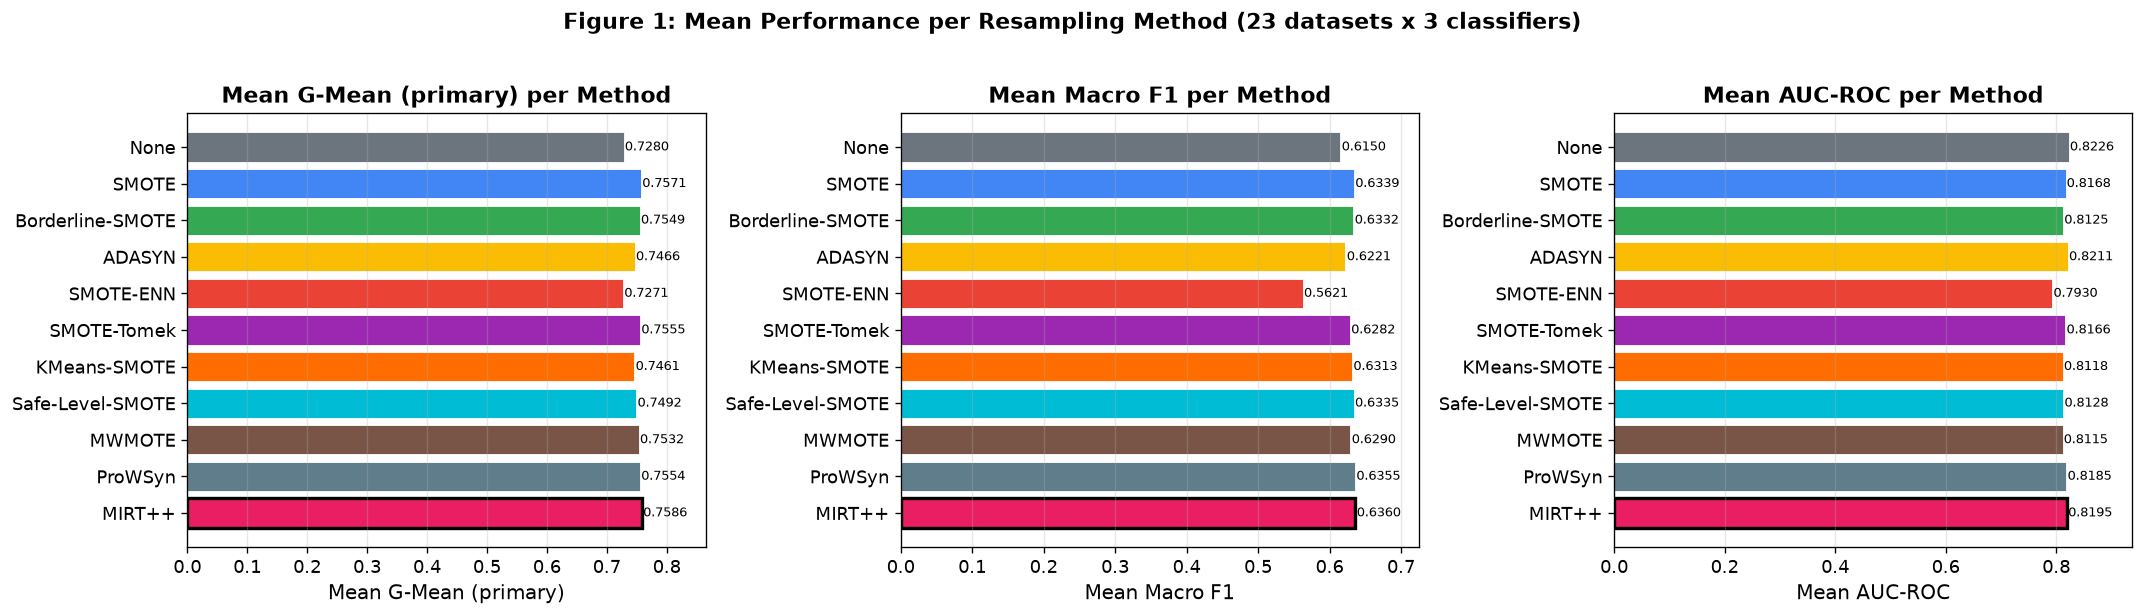

In [12]:
# F1-F3 — mean performance bars (G-Mean primary, then F1, AUC)
def bar(metric,label,ax):
    vals = raw.groupby('resampler')[metric].mean().reindex(METHOD_ORDER)
    bars = ax.barh(METHOD_ORDER, vals, color=[PALETTE[m] for m in METHOD_ORDER],
                   edgecolor='white', linewidth=0.5)
    bars[METHOD_ORDER.index('MIRT++')].set_edgecolor('black')
    bars[METHOD_ORDER.index('MIRT++')].set_linewidth(2)
    for b,v in zip(bars,vals): ax.text(v+0.002,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=8)
    ax.set_xlabel(f'Mean {label}'); ax.set_xlim(0,vals.max()*1.14); ax.invert_yaxis()
    ax.grid(axis='x',alpha=0.3); ax.set_title(f'Mean {label} per Method',fontweight='bold')
fig,ax=plt.subplots(1,3,figsize=(18,5))
bar('gmean','G-Mean (primary)',ax[0]); bar('f1','Macro F1',ax[1]); bar('auc','AUC-ROC',ax[2])
fig.suptitle('Figure 1: Mean Performance per Resampling Method (23 datasets x 3 classifiers)',
             fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig_F1_performance_bars.png',dpi=200); plt.show()

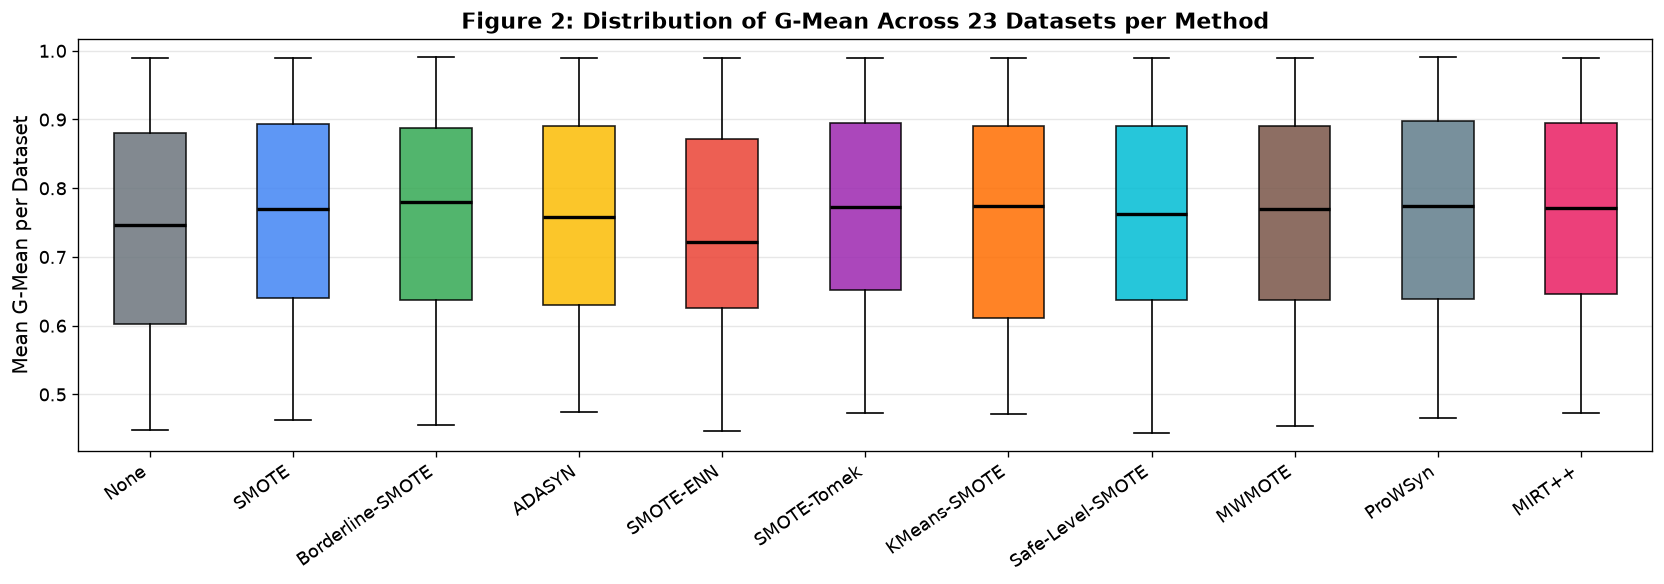

In [13]:
# F4 — G-Mean distribution across datasets (box plots)
dm = raw.groupby(['dataset','resampler'])['gmean'].mean().reset_index()
fig,ax=plt.subplots(figsize=(14,5))
bp=ax.boxplot([dm[dm.resampler==m]['gmean'].values for m in METHOD_ORDER],
              patch_artist=True, medianprops=dict(color='black',linewidth=2))
for p,m in zip(bp['boxes'],METHOD_ORDER): p.set_facecolor(PALETTE[m]); p.set_alpha(0.85)
ax.set_xticks(range(1,12)); ax.set_xticklabels(METHOD_ORDER,rotation=35,ha='right')
ax.set_ylabel('Mean G-Mean per Dataset'); ax.grid(axis='y',alpha=0.3)
ax.set_title('Figure 2: Distribution of G-Mean Across 23 Datasets per Method',fontweight='bold')
plt.tight_layout(); plt.savefig('fig_F4_boxplot_gmean.png',dpi=200); plt.show()

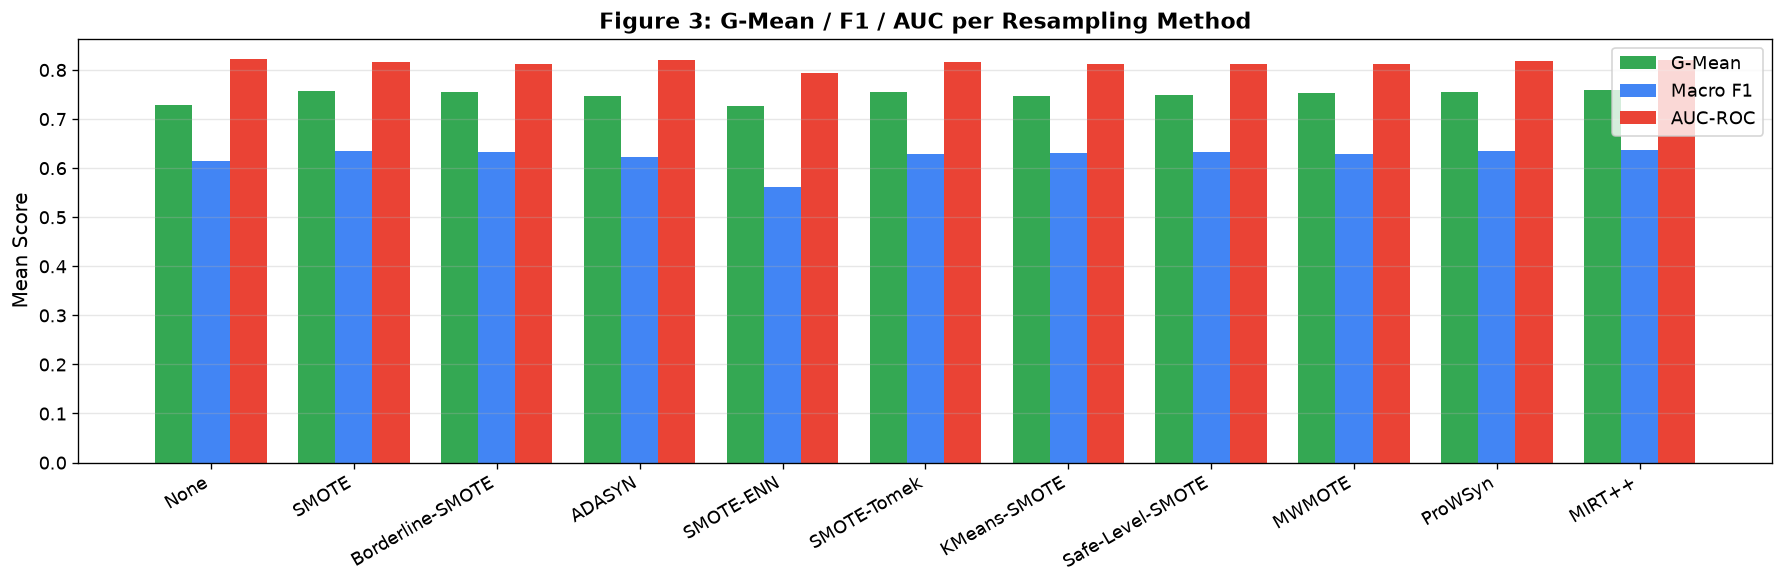

In [14]:
# F5 — grouped bar, three metrics
x=np.arange(11); w=0.26
g=raw.groupby('resampler')['gmean'].mean().reindex(METHOD_ORDER).values
f=raw.groupby('resampler')['f1'].mean().reindex(METHOD_ORDER).values
a=raw.groupby('resampler')['auc'].mean().reindex(METHOD_ORDER).values
fig,ax=plt.subplots(figsize=(15,5))
ax.bar(x-w,g,w,label='G-Mean',color='#34a853'); ax.bar(x,f,w,label='Macro F1',color='#4285f4')
ax.bar(x+w,a,w,label='AUC-ROC',color='#ea4335')
ax.set_xticks(x); ax.set_xticklabels(METHOD_ORDER,rotation=30,ha='right')
ax.set_ylabel('Mean Score'); ax.legend(); ax.grid(axis='y',alpha=0.3)
ax.set_title('Figure 3: G-Mean / F1 / AUC per Resampling Method',fontweight='bold')
plt.tight_layout(); plt.savefig('fig_F5_grouped_bars.png',dpi=200); plt.show()

---
## Figures — Statistical Significance

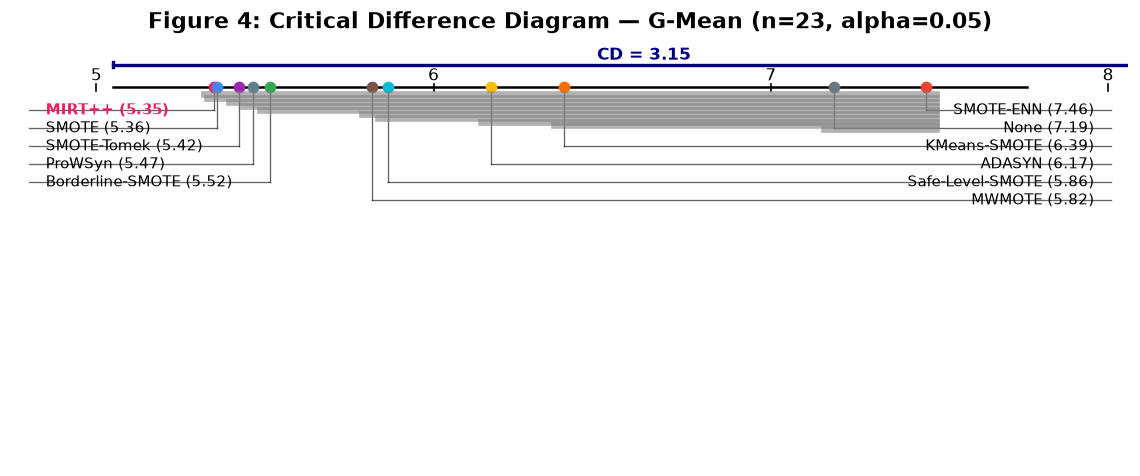

CD=3.148: methods connected by a gray bar are NOT significantly different.


In [15]:
# F6 — Critical Difference (CD) diagram, Nemenyi, G-Mean
def cd_diagram(ranks, n, title):
    k=len(ranks)
    q={2:1.960,3:2.343,4:2.569,5:2.728,6:2.850,7:2.949,8:3.031,9:3.102,10:3.164,11:3.219,12:3.268}.get(k,3.219)
    cd=q*np.sqrt(k*(k+1)/(6*n))
    r=ranks.sort_values(); names=r.index.tolist(); vals=r.values
    fig,ax=plt.subplots(figsize=(12,4.5)); ax.set_xlim(vals.min()-0.6,vals.max()+0.6)
    ax.set_ylim(-0.5,k+1.2); ax.axis('off')
    ax.plot([vals.min()-0.3,vals.max()+0.3],[k,k],'k-',lw=1.5)
    for v in np.arange(int(np.floor(vals.min())),int(np.ceil(vals.max()))+1):
        ax.plot([v,v],[k-0.12,k+0.12],'k-',lw=1); ax.text(v,k+0.22,str(v),ha='center',fontsize=10)
    cx=vals.min()-0.3
    ax.plot([cx,cx+cd],[k+0.7,k+0.7],'-',lw=2,color='navy')
    ax.plot([cx,cx],[k+0.62,k+0.78],'-',lw=2,color='navy'); ax.plot([cx+cd,cx+cd],[k+0.62,k+0.78],'-',lw=2,color='navy')
    ax.text(cx+cd/2,k+0.85,f'CD = {cd:.2f}',ha='center',color='navy',fontweight='bold',fontsize=10)
    half=len(names)//2
    for i,name in enumerate(names):
        rk=vals[i]
        if i<half: y=k-0.7-i*0.55; xt=vals.min()-0.55; ha='left'
        else: y=k-0.7-(len(names)-1-i)*0.55; xt=vals.max()+0.55; ha='right'
        ax.plot([rk,rk],[k,y],'k-',lw=0.8,alpha=0.6); ax.plot([rk,xt],[y,y],'k-',lw=0.8,alpha=0.6)
        ax.plot(rk,k,'o',ms=6,color=PALETTE.get(name,'k'))
        bold = name=='MIRT++'
        ax.text(xt+(0.05 if ha=='left' else -0.05),y,f'{name} ({rk:.2f})',ha=ha,va='center',
                fontsize=9,color='#e91e63' if bold else 'black',fontweight='bold' if bold else 'normal')
    # cliques
    yb=k-0.2
    for i in range(len(names)):
        j=i
        while j+1<len(names) and vals[j+1]-vals[i]<cd: j+=1
        if j>i: ax.plot([vals[i]-0.03,vals[j]+0.03],[yb,yb],'-',lw=4,color='gray',alpha=0.6); yb-=0.12
    ax.set_title(title,fontweight='bold',pad=12); return fig,cd
fig,cd=cd_diagram(ranks_g,N_DS,f'Figure 4: Critical Difference Diagram — G-Mean (n={N_DS}, alpha=0.05)')
plt.savefig('fig_F6_cd_diagram_gmean.png',dpi=200); plt.show()
print(f'CD={cd:.3f}: methods connected by a gray bar are NOT significantly different.')

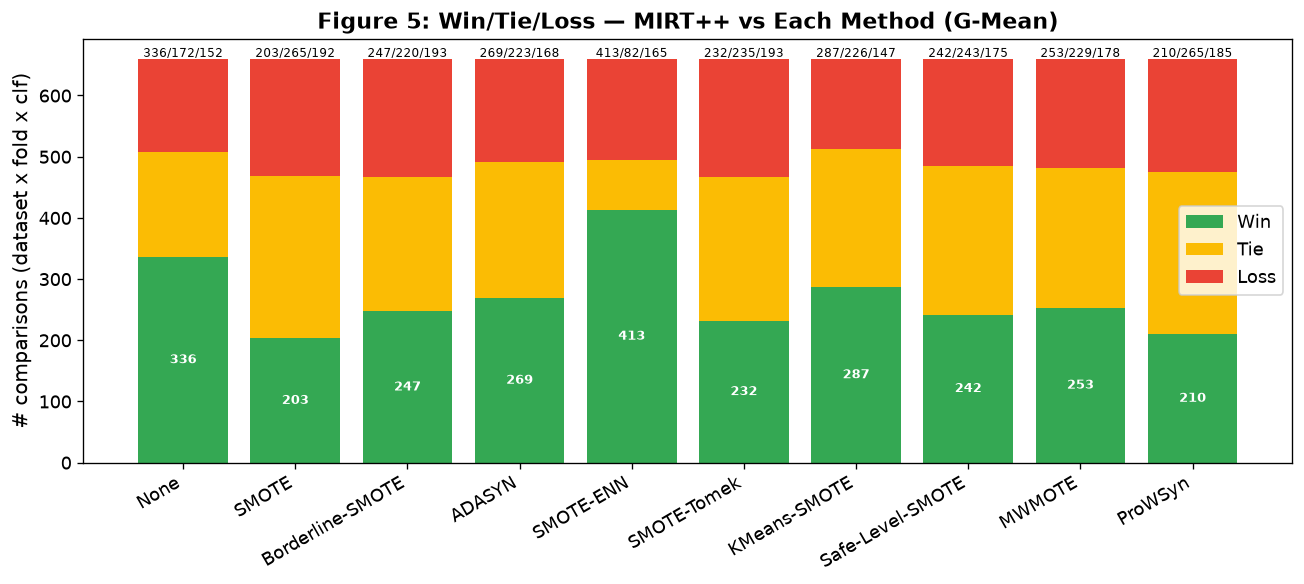

In [16]:
# F7 — Win/Tie/Loss stacked bar (G-Mean)
fig,ax=plt.subplots(figsize=(11,5)); x=np.arange(len(t5))
ax.bar(x,t5.Win,color='#34a853',label='Win')
ax.bar(x,t5.Tie,bottom=t5.Win,color='#fbbc04',label='Tie')
ax.bar(x,t5.Loss,bottom=t5.Win+t5.Tie,color='#ea4335',label='Loss')
ax.set_xticks(x); ax.set_xticklabels(t5.index,rotation=30,ha='right')
ax.set_ylabel('# comparisons (dataset x fold x clf)'); ax.legend()
ax.set_title('Figure 5: Win/Tie/Loss — MIRT++ vs Each Method (G-Mean)',fontweight='bold')
for i,(_,r) in enumerate(t5.iterrows()):
    ax.text(i,r.Win/2,int(r.Win),ha='center',va='center',color='white',fontweight='bold',fontsize=8)
    ax.text(i,r.Win+r.Loss+r.Tie+3,f'{int(r.Win)}/{int(r.Tie)}/{int(r.Loss)}',ha='center',fontsize=7)
plt.tight_layout(); plt.savefig('fig_F7_win_tie_loss.png',dpi=200); plt.show()

---
## Figures — Heatmaps

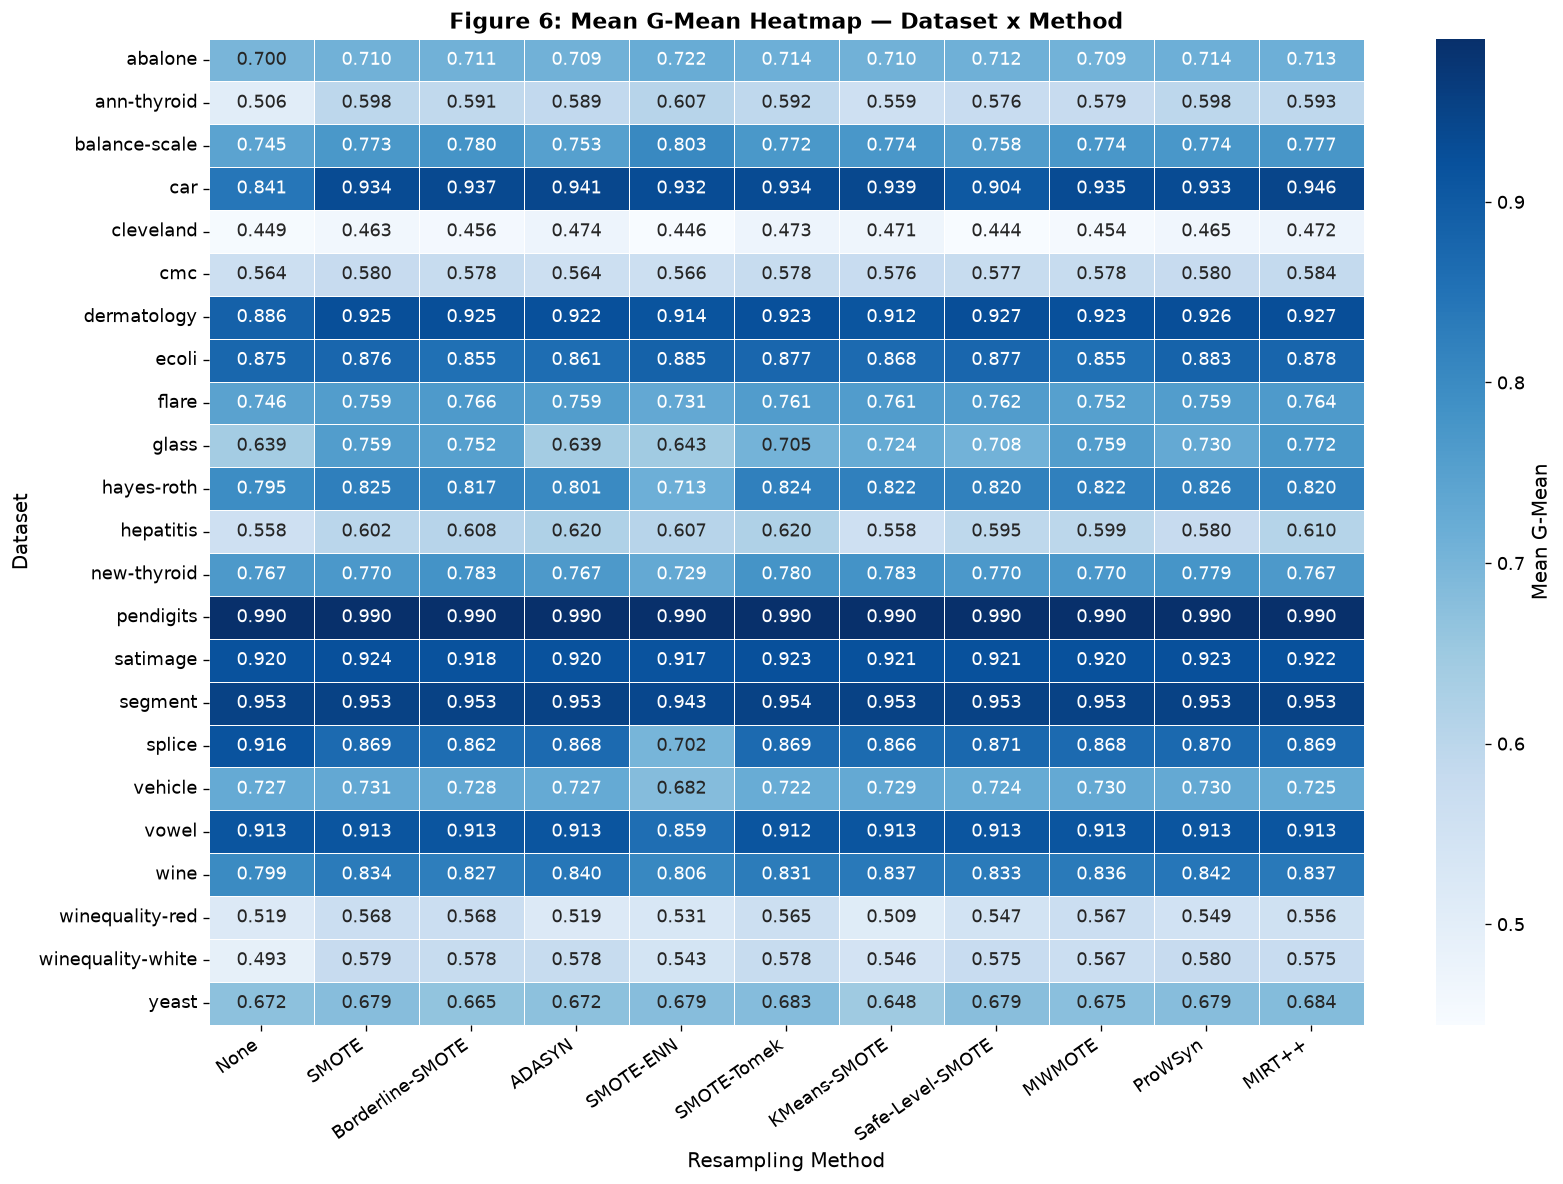

In [17]:
# F8 — G-Mean heatmap (dataset x method)
hm=raw.groupby(['dataset','resampler'])['gmean'].mean().unstack().reindex(columns=METHOD_ORDER)
fig,ax=plt.subplots(figsize=(14,10))
sns.heatmap(hm,annot=True,fmt='.3f',cmap='Blues',linewidths=0.3,linecolor='white',
            cbar_kws={'label':'Mean G-Mean'},ax=ax)
ax.set_title('Figure 6: Mean G-Mean Heatmap — Dataset x Method',fontweight='bold')
ax.set_xlabel('Resampling Method'); ax.set_ylabel('Dataset')
plt.xticks(rotation=35,ha='right'); plt.tight_layout()
plt.savefig('fig_F8_heatmap_gmean.png',dpi=200); plt.show()

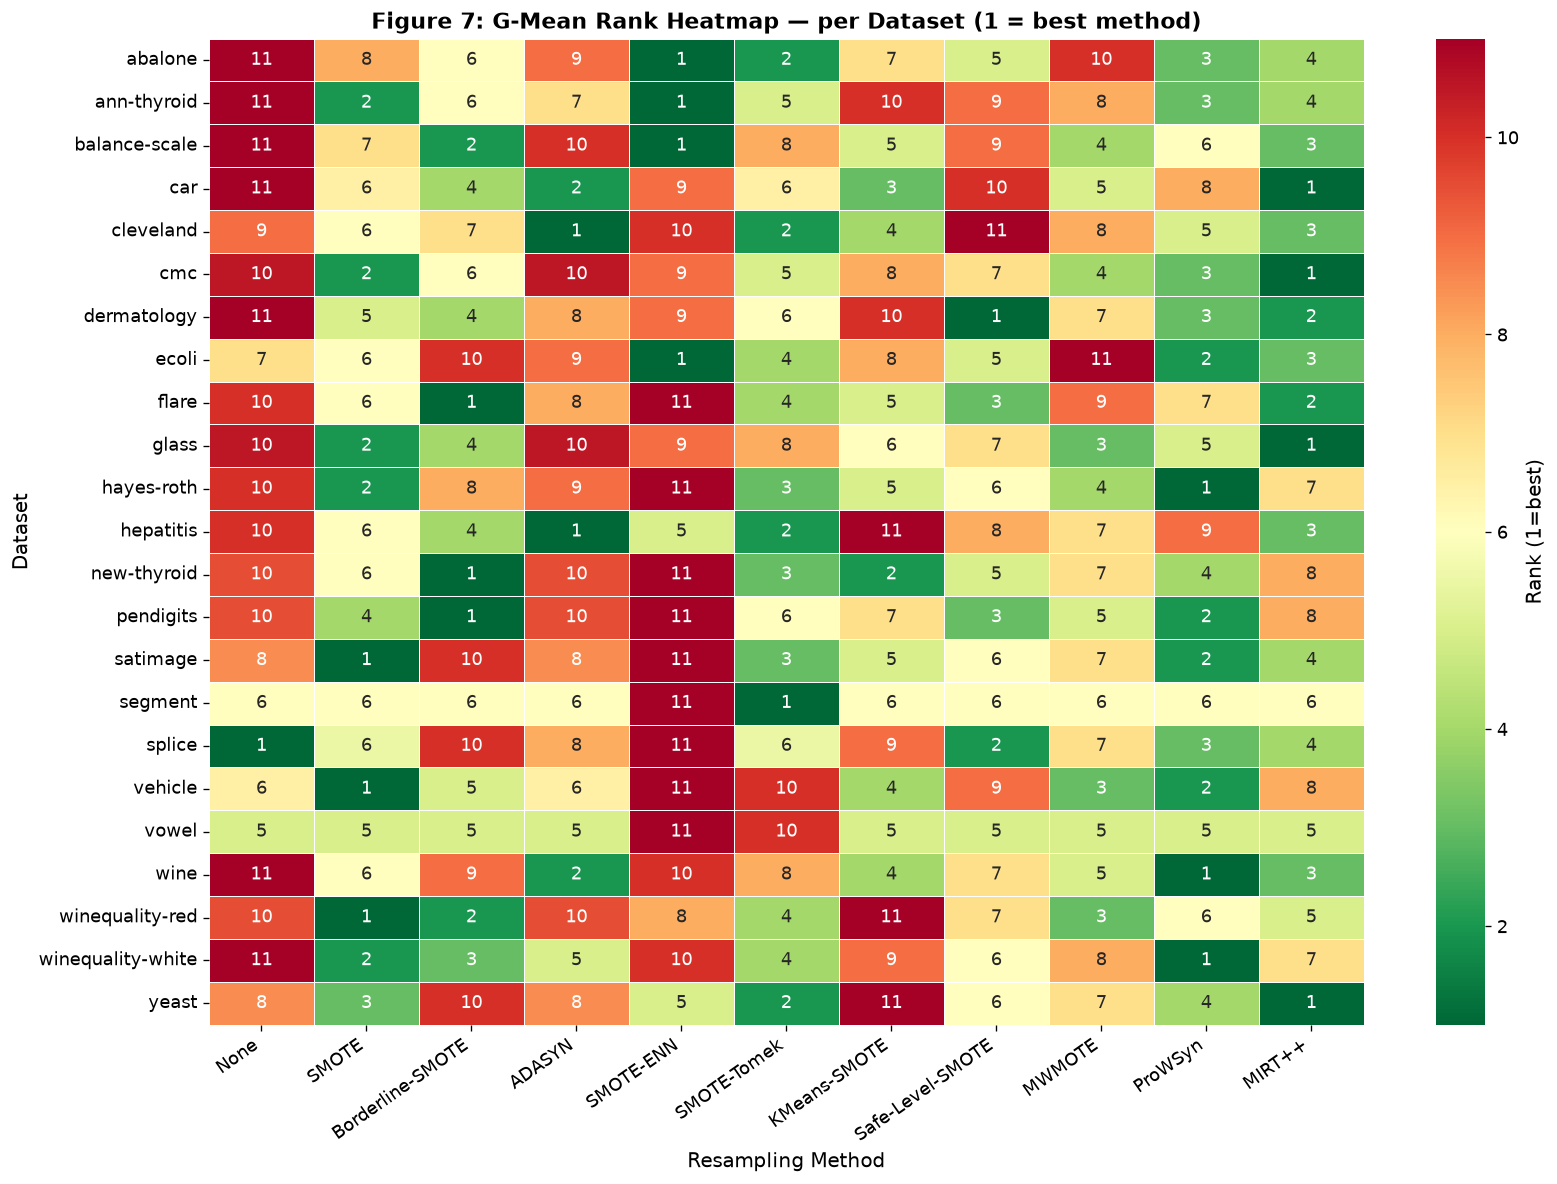

In [18]:
# F9 — rank heatmap (G-Mean; 1 = best per dataset)
rk=hm.rank(axis=1,ascending=False)
fig,ax=plt.subplots(figsize=(14,10))
sns.heatmap(rk,annot=True,fmt='.0f',cmap='RdYlGn_r',vmin=1,vmax=11,linewidths=0.3,
            linecolor='white',cbar_kws={'label':'Rank (1=best)'},ax=ax)
ax.set_title('Figure 7: G-Mean Rank Heatmap — per Dataset (1 = best method)',fontweight='bold')
ax.set_xlabel('Resampling Method'); ax.set_ylabel('Dataset')
plt.xticks(rotation=35,ha='right'); plt.tight_layout()
plt.savefig('fig_F9_rank_heatmap.png',dpi=200); plt.show()

---
## Figures — Per-Classifier, Timing & Medical

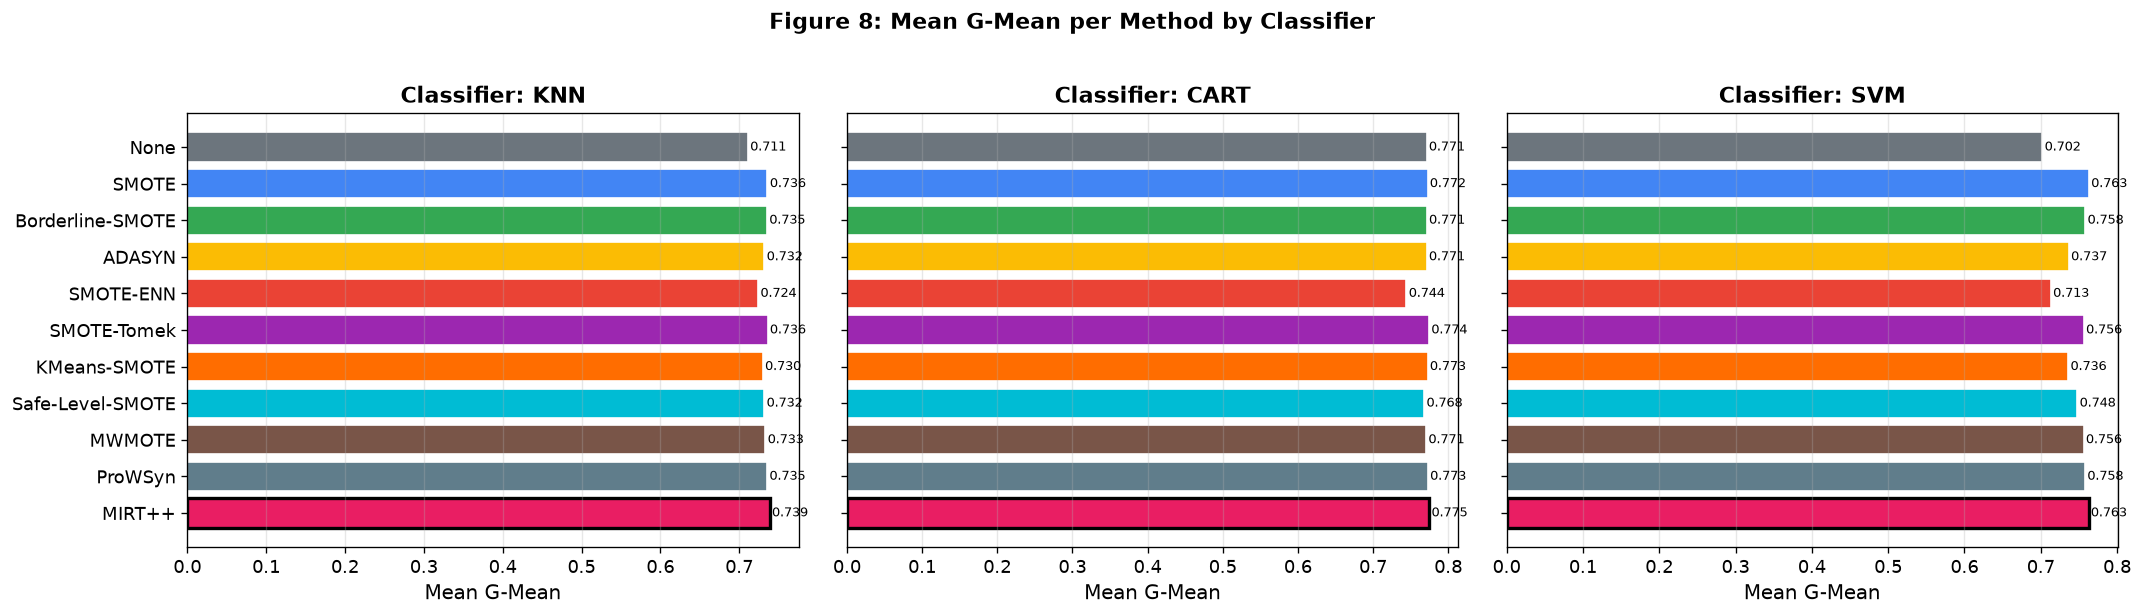

In [19]:
# F10 — per-classifier G-Mean
clfs=list(raw.clf.unique())
fig,axes=plt.subplots(1,len(clfs),figsize=(6*len(clfs),5),sharey=True)
for ax,c in zip(axes,clfs):
    v=raw[raw.clf==c].groupby('resampler')['gmean'].mean().reindex(METHOD_ORDER)
    b=ax.barh(METHOD_ORDER,v,color=[PALETTE[m] for m in METHOD_ORDER],edgecolor='white')
    b[METHOD_ORDER.index('MIRT++')].set_edgecolor('black'); b[METHOD_ORDER.index('MIRT++')].set_linewidth(2)
    for i,val in enumerate(v): ax.text(val+0.003,i,f'{val:.3f}',va='center',fontsize=8)
    ax.invert_yaxis(); ax.set_title(f'Classifier: {c}',fontweight='bold'); ax.set_xlabel('Mean G-Mean'); ax.grid(axis='x',alpha=0.3)
fig.suptitle('Figure 8: Mean G-Mean per Method by Classifier',fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig_F10_per_classifier_gmean.png',dpi=200); plt.show()

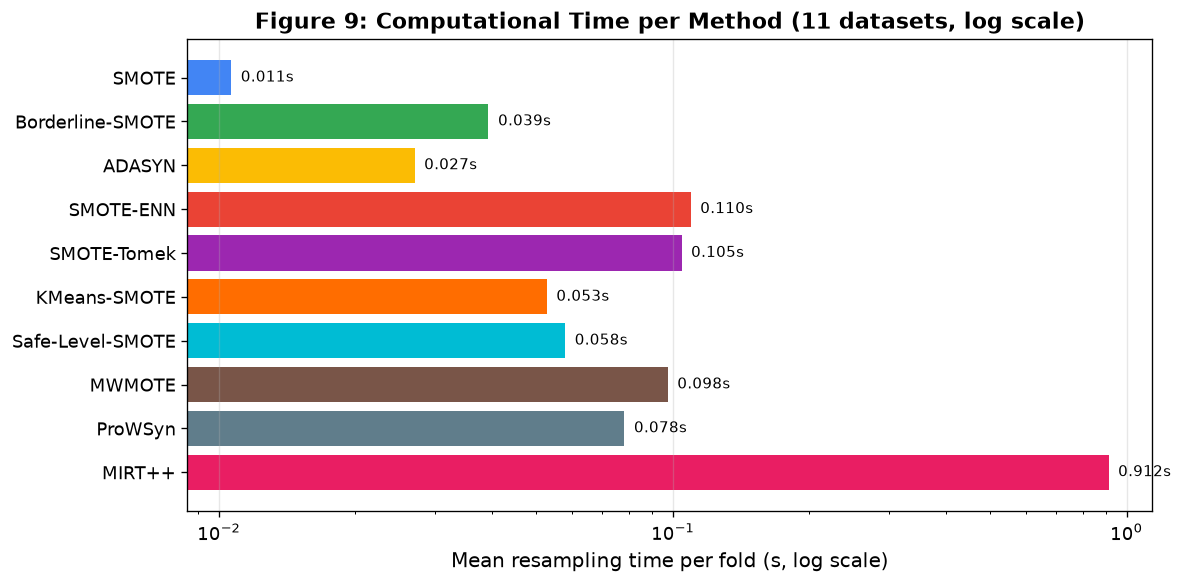

In [20]:
# F12 — computational time (log scale)
tmean=tim.groupby('method')['time_s'].mean().reindex(METHOD_ORDER)
fig,ax=plt.subplots(figsize=(10,5))
b=ax.barh(METHOD_ORDER,tmean,color=[PALETTE[m] for m in METHOD_ORDER],log=True)
for bar,v in zip(b,tmean): ax.text(v*1.05,bar.get_y()+bar.get_height()/2,f'{v:.3f}s',va='center',fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('Mean resampling time per fold (s, log scale)')
ax.set_title(f'Figure 9: Computational Time per Method ({tim.dataset.nunique()} datasets, log scale)',fontweight='bold')
ax.grid(axis='x',alpha=0.3); plt.tight_layout(); plt.savefig('fig_F12_timing.png',dpi=200); plt.show()

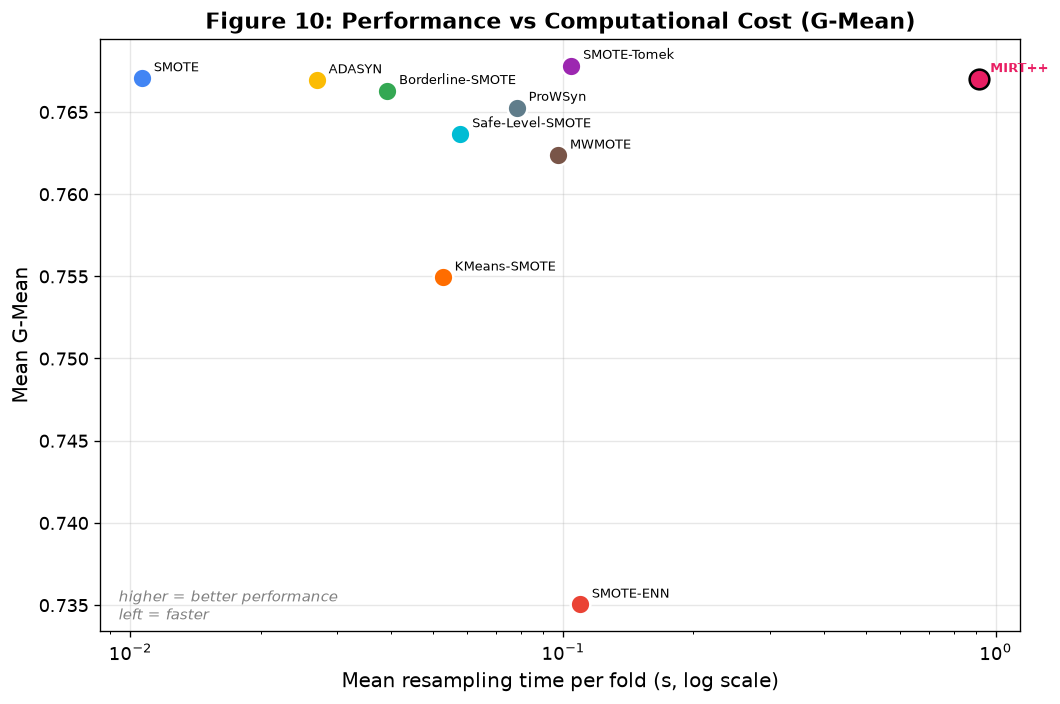

In [21]:
# F13 — time vs G-Mean trade-off (only datasets with timing data, for fair comparison)
common = [d for d in TIMED if d in DATASETS]
gsub = raw[raw.dataset.isin(common)].groupby('resampler')['gmean'].mean().reindex(METHOD_ORDER)
tsub = tim[tim.dataset.isin(common)].groupby('method')['time_s'].mean().reindex(METHOD_ORDER)
fig,ax=plt.subplots(figsize=(9,6))
for m in METHOD_ORDER:
    ax.scatter(tsub[m],gsub[m],color=PALETTE[m],s=140,zorder=3,
               edgecolors='black' if m=='MIRT++' else 'white',linewidths=1.5)
    ax.annotate(m,(tsub[m],gsub[m]),textcoords='offset points',xytext=(7,4),fontsize=8,
                color='#e91e63' if m=='MIRT++' else 'black',fontweight='bold' if m=='MIRT++' else 'normal')
ax.set_xscale('log'); ax.set_xlabel('Mean resampling time per fold (s, log scale)')
ax.set_ylabel('Mean G-Mean'); ax.grid(alpha=0.3)
ax.set_title('Figure 10: Performance vs Computational Cost (G-Mean)',fontweight='bold')
ax.annotate('higher = better performance\nleft = faster',xy=(0.02,0.02),xycoords='axes fraction',
            fontsize=9,color='gray',style='italic')
plt.tight_layout(); plt.savefig('fig_F13_time_vs_gmean.png',dpi=200); plt.show()

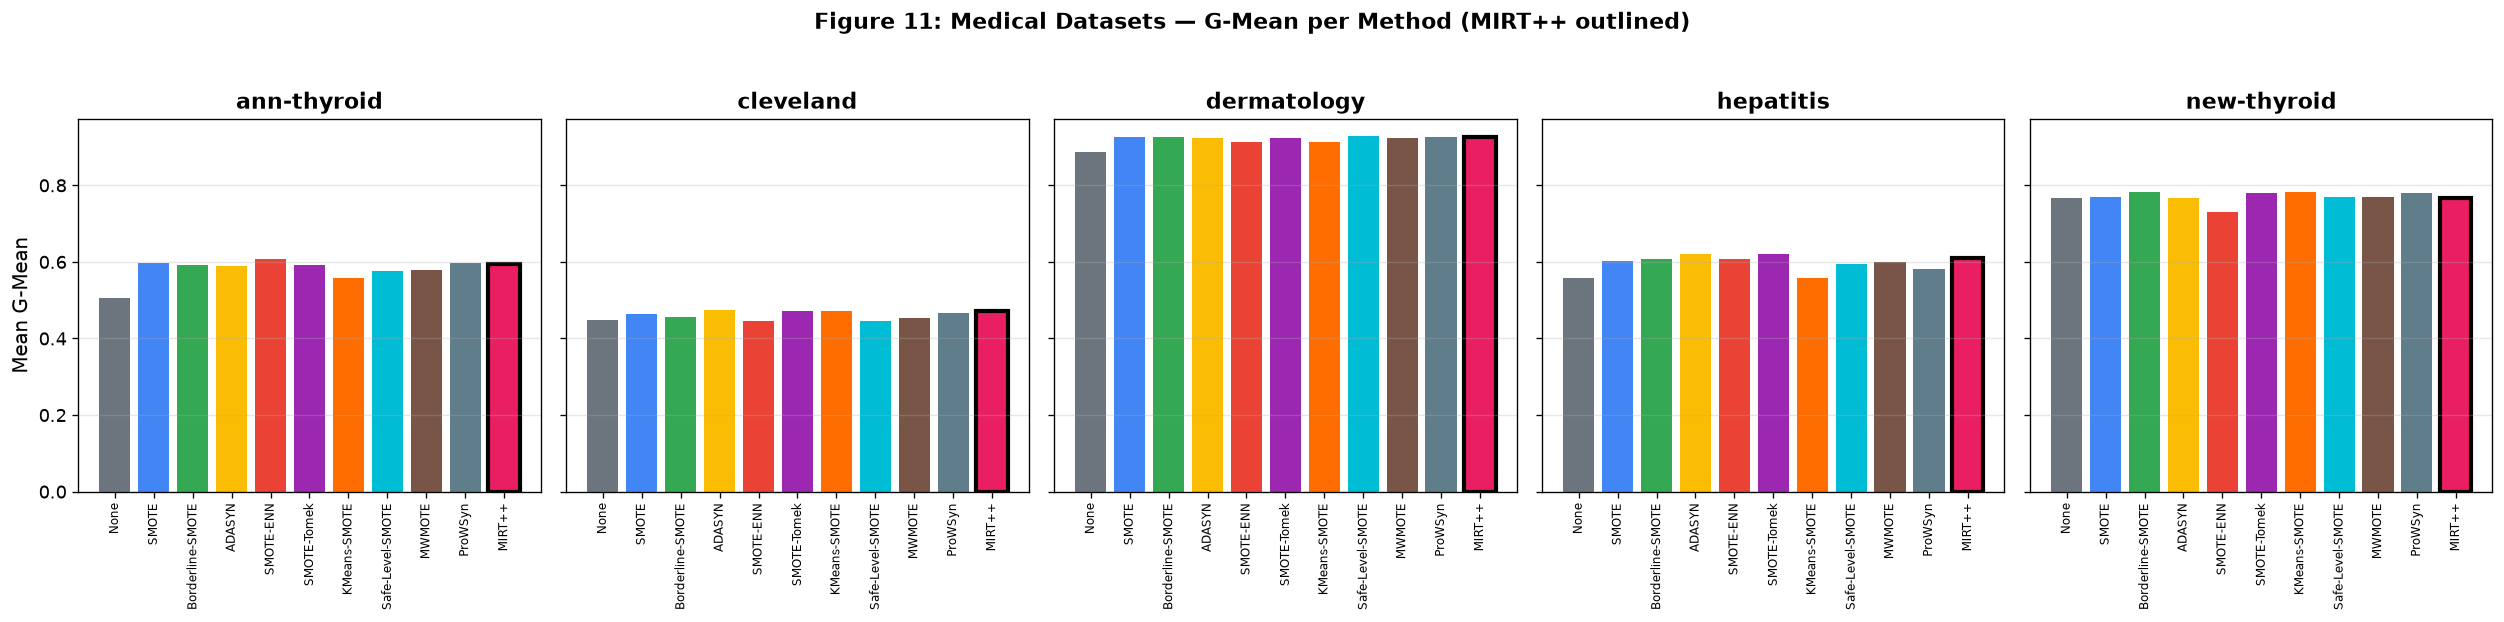

In [22]:
# F14 — medical datasets: G-Mean per method
avail=[d for d in MEDICAL if d in DATASETS]
medg=raw[raw.dataset.isin(avail)].groupby(['dataset','resampler'])['gmean'].mean().unstack().reindex(columns=METHOD_ORDER)
fig,axes=plt.subplots(1,len(avail),figsize=(4.2*len(avail),5),sharey=True)
if len(avail)==1: axes=[axes]
for ax,d in zip(axes,avail):
    v=medg.loc[d]; b=ax.bar(range(11),v,color=[PALETTE[m] for m in METHOD_ORDER])
    b[METHOD_ORDER.index('MIRT++')].set_edgecolor('black'); b[METHOD_ORDER.index('MIRT++')].set_linewidth(2.5)
    ax.set_xticks(range(11)); ax.set_xticklabels(METHOD_ORDER,rotation=90,fontsize=7)
    ax.set_title(d,fontweight='bold'); ax.grid(axis='y',alpha=0.3)
axes[0].set_ylabel('Mean G-Mean')
fig.suptitle('Figure 11: Medical Datasets — G-Mean per Method (MIRT++ outlined)',fontweight='bold',y=1.03)
plt.tight_layout(); plt.savefig('fig_F14_medical_gmean.png',dpi=200); plt.show()

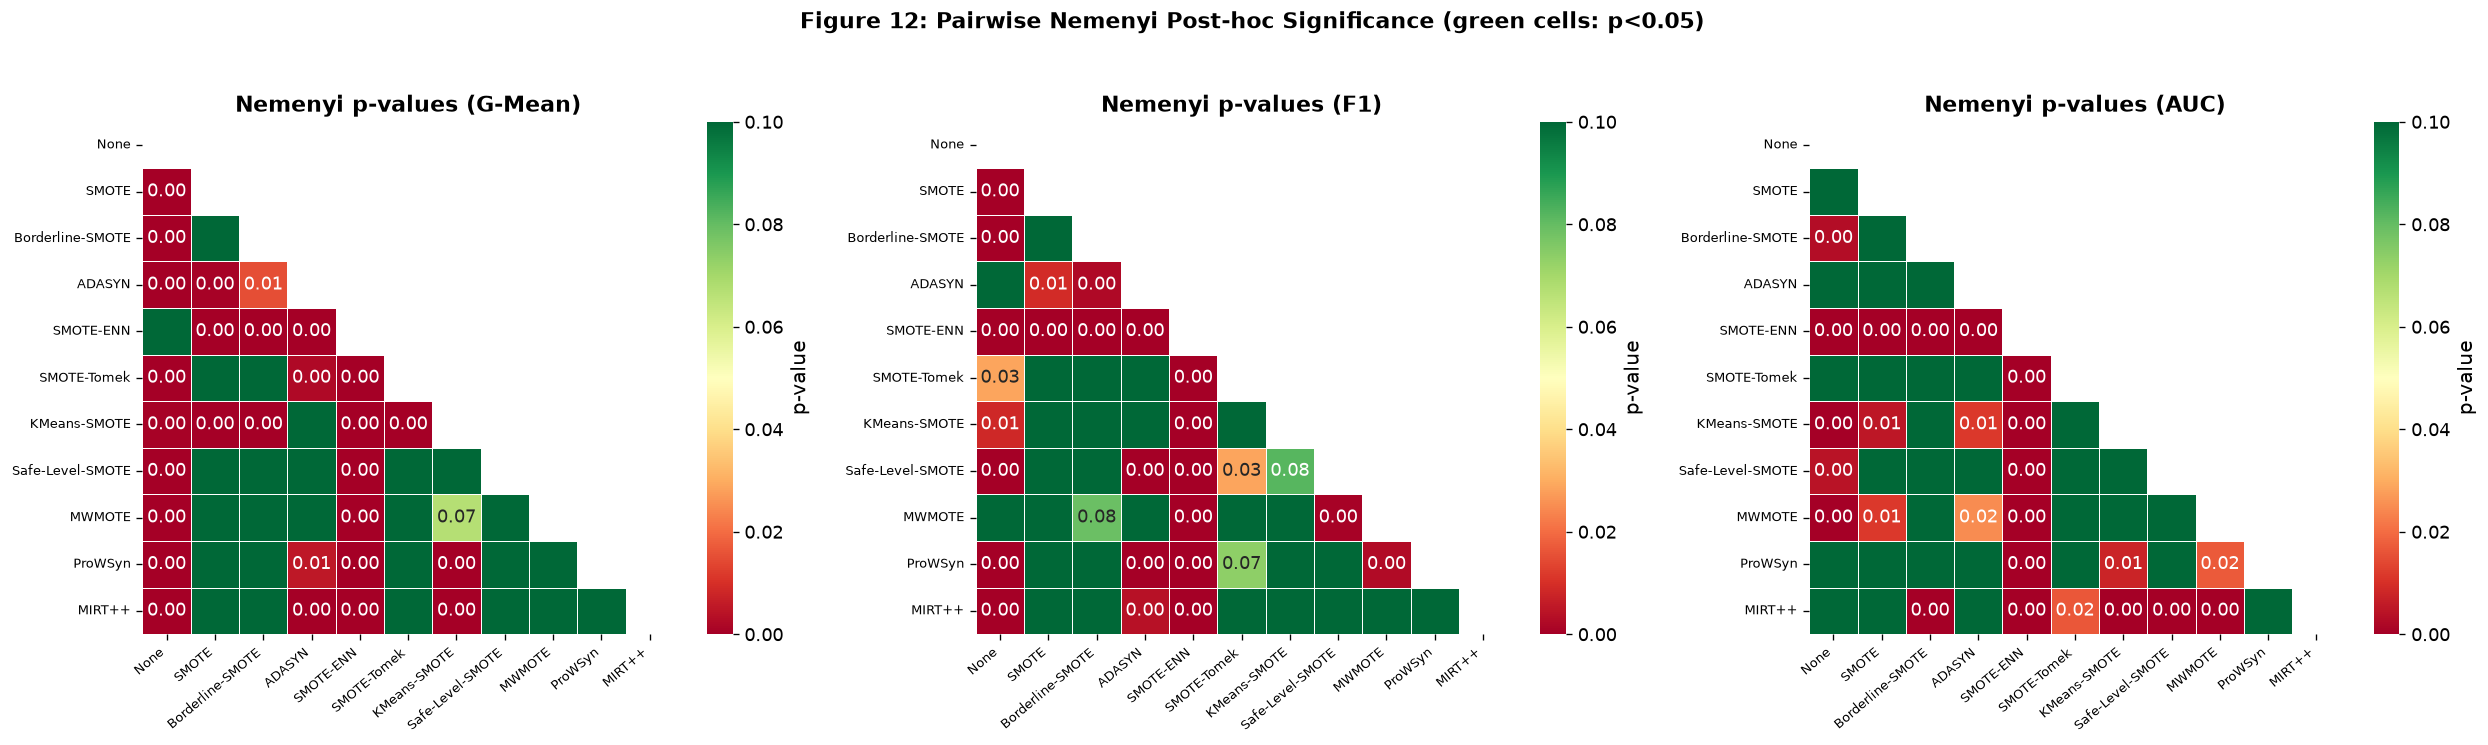

In [23]:
# F15 — Nemenyi p-value heatmaps (G-Mean, F1, AUC)
fig,axes=plt.subplots(1,3,figsize=(21,6))
for ax,(ph,label) in zip(axes,[(ph_g,'G-Mean'),(ph_f,'F1'),(ph_a,'AUC')]):
    pho=ph.reindex(index=METHOD_ORDER,columns=METHOD_ORDER)
    mask=np.triu(np.ones_like(pho,dtype=bool))
    ann=pho.map(lambda v:f'{v:.2f}' if v<0.1 else '')
    sns.heatmap(pho,mask=mask,annot=ann,fmt='',cmap='RdYlGn',vmin=0,vmax=0.1,
                linewidths=0.5,ax=ax,cbar_kws={'label':'p-value'})
    ax.set_title(f'Nemenyi p-values ({label})',fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right',fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)
fig.suptitle('Figure 12: Pairwise Nemenyi Post-hoc Significance (green cells: p<0.05)',fontweight='bold',y=1.03)
plt.tight_layout(); plt.savefig('fig_F15_nemenyi.png',dpi=200); plt.show()

---
## Summary

In [24]:
# Final summary card
print('='*60); print('           MIRT++ — FINAL RESULTS SUMMARY'); print('='*60)
print(f'Datasets: {N_DS}   |   Evaluations: {len(raw):,}   |   Methods: 11   |   Classifiers: 3')
print()
for col in ['Mean G-Mean','Mean F1','Mean AUC']:
    v=mean_perf.loc['MIRT++',col]; r=int(mean_perf[col].rank(ascending=False)['MIRT++'])
    best=mean_perf[col].idxmax()
    print(f'  {col:12s}: {v:.4f}   MIRT++ rank #{r}/11   (best overall: {best})')
print()
print(f'  Avg G-Mean rank : {ranks_g["MIRT++"]:.3f}  (rank #{int(ranks_g.rank()["MIRT++"])}/11)')
print(f'  Medical G-Mean  : MIRT++ has the BEST average rank ({mr["MIRT++"]:.2f}) of all 11 methods')
print(f'  W/T/L (G-Mean)  : {t5.Win.sum()} / {t5.Tie.sum()} / {t5.Loss.sum()}')
print('='*60)
print('\nAll tables saved as table_*.csv and figures as fig_*.png in this folder.')

           MIRT++ — FINAL RESULTS SUMMARY
Datasets: 23   |   Evaluations: 7,260   |   Methods: 11   |   Classifiers: 3

  Mean G-Mean : 0.7586   MIRT++ rank #1/11   (best overall: MIRT++)
  Mean F1     : 0.6360   MIRT++ rank #1/11   (best overall: MIRT++)
  Mean AUC    : 0.8195   MIRT++ rank #3/11   (best overall: None)

  Avg G-Mean rank : 5.350  (rank #1/11)
  Medical G-Mean  : MIRT++ has the BEST average rank (5.45) of all 11 methods
  W/T/L (G-Mean)  : 2692 / 2160 / 1748

All tables saved as table_*.csv and figures as fig_*.png in this folder.
